In [52]:
import pandas as pd
import matplotlib.pyplot as plt

In [54]:
url = 'https://drive.google.com/uc?id=1UZuosGdSc8CSVofDBNDx6Ju_YtkwTL56'

df = pd.read_csv(url)
df.head(30)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Home Type            296 non-null    object 
 1   Zip                  296 non-null    int64  
 2   Listing Price        296 non-null    int64  
 3   Baths                294 non-null    float64
 4   Beds                 296 non-null    int64  
 5   SQFT                 294 non-null    float64
 6   Year Built           273 non-null    float64
 7   Airbnb Cash on Cash  296 non-null    float64
dtypes: float64(4), int64(3), object(1)
memory usage: 18.6+ KB


In [30]:
df.describe()

,Zip,Listing Price,Baths,Beds,SQFT,Year Built,Airbnb Cash on Cash
count,296.000000,296.000000,294.000000,296.000000,294.000000,273.000000,296.000000
mean,61821.304054,225782.037162,1.969388,3.175676,2002.656463,1979.472527,7.371624
std,0.742500,147640.909051,1.434252,0.705583,994.326109,30.089697,6.247464
min,61820.000000,77100.000000,0.000000,1.000000,704.000000,1855.000000,-1.125820
25%,61821.000000,119999.750000,1.000000,3.000000,1322.500000,1960.000000,2.284272
50%,61821.000000,172350.000000,2.000000,3.000000,1704.000000,1985.000000,5.056220
75%,61822.000000,285675.000000,3.000000,4.000000,2396.000000,2004.000000,12.357400
max,61822.000000,989000.000000,6.000000,4.000000,7040.000000,2017.000000,25.179400


In [31]:
top_10_cash = (
    df.dropna(subset=["Airbnb Cash on Cash"])
      .sort_values(by="Airbnb Cash on Cash", ascending=False)
      .head(10)
)

print(top_10_cash)


                     Home Type    Zip  Listing Price  Baths  Beds    SQFT  \
57   Single Family Residential  61821          77500    1.0     3   968.0   
154  Single Family Residential  61821          79500    1.0     3   940.0   
35   Single Family Residential  61821          79500    1.0     3   999.0   
194  Single Family Residential  61820          85000    1.0     3  1008.0   
285                 Condo/Coop  61820          79900    0.0     3  1319.0   
153  Single Family Residential  61821          89900    1.0     3   936.0   
119  Single Family Residential  61821          89900    1.0     3  1366.0   
121  Single Family Residential  61821          89900    2.0     3  1554.0   
12   Single Family Residential  61821          92900    1.0     3  1084.0   
115  Single Family Residential  61821          94900    1.0     3  1025.0   

     Year Built  Airbnb Cash on Cash  
57       1979.0              25.1794  
154      1960.0              24.4904  
35       1959.0              24.490

In [35]:
df_clean = df.dropna(subset=["Airbnb Cash on Cash", "Listing Price"])

top_10_best_deals = (
    df_clean
    .sort_values(
        by=["Airbnb Cash on Cash", "Listing Price"],
        ascending=[False, True]   # High return, Low price
    )
    .head(10)
    [["Zip", "Beds", "SQFT", "Listing Price", "Airbnb Cash on Cash"]]
)

top_10_best_deals


,Zip,Beds,SQFT,Listing Price,Airbnb Cash on Cash
57,61821,3,968.0,77500,25.1794
35,61821,3,999.0,79500,24.4904
154,61821,3,940.0,79500,24.4904
194,61820,3,1008.0,85000,22.7627
285,61820,3,1319.0,79900,21.5632
119,61821,3,1366.0,89900,21.4016
121,61821,3,1554.0,89900,21.4016
153,61821,3,936.0,89900,21.4016
12,61821,3,1084.0,92900,20.6391
115,61821,3,1025.0,94900,20.1575


<Axes: xlabel='Listing Price', ylabel='Airbnb Cash on Cash'>

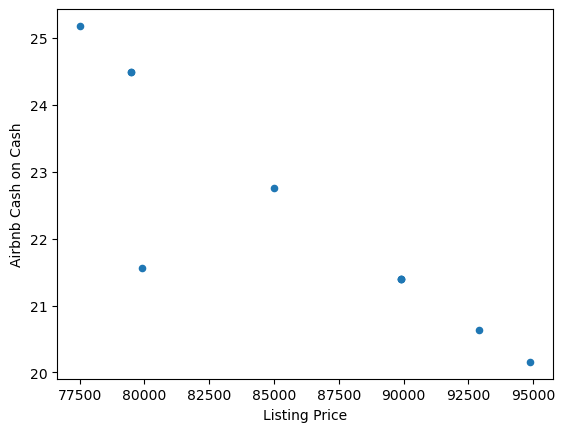

In [41]:
top_10_best_deals.plot(
    kind='scatter',
    x='Listing Price',
    y='Airbnb Cash on Cash'
)




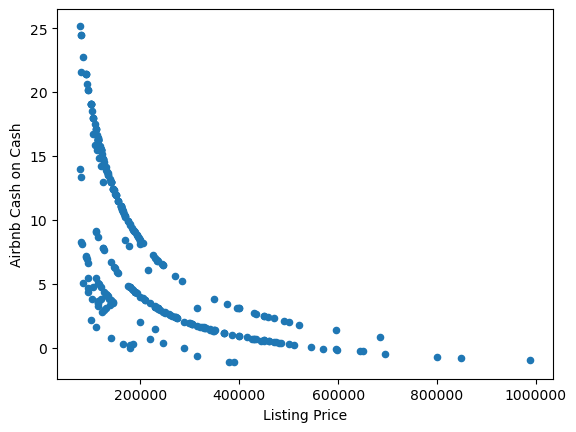

In [45]:
import matplotlib.pyplot as plt

df.plot(kind='scatter', x='Listing Price', y='Airbnb Cash on Cash')

plt.ticklabel_format(style='plain', axis='x')

plt.show()



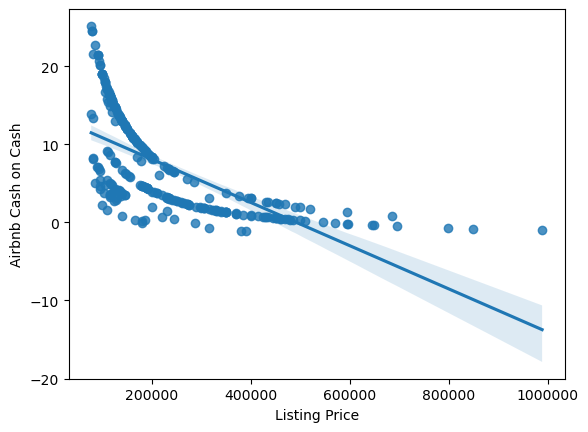

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(data=df, x='Listing Price', y='Airbnb Cash on Cash')

plt.ticklabel_format(style='plain', axis='x')

plt.show()




In [47]:
import statsmodels.api as sm

df_reg = df.dropna(subset=["Listing Price", "Airbnb Cash on Cash"])

X = df_reg["Listing Price"]
X = sm.add_constant(X)

y = df_reg["Airbnb Cash on Cash"]

model = sm.OLS(y, X).fit()

print(model.summary())


                             OLS Regression Results                            
Dep. Variable:     Airbnb Cash on Cash   R-squared:                       0.427
Model:                             OLS   Adj. R-squared:                  0.425
Method:                  Least Squares   F-statistic:                     219.2
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):           1.92e-37
Time:                         16:53:46   Log-Likelihood:                -879.37
No. Observations:                  296   AIC:                             1763.
Df Residuals:                      294   BIC:                             1770.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            13.6158      0.504 

In [ ]:
# Conclusion from this regression: R2 value of .427 means that 42.7% of the variance in return is  
# based on listing price- listing prices Coefficient of -2.766e-05  means that cash on cash return 
# decreases by 2.77 for every $100,000 in listing price 

In [49]:
import statsmodels.api as sm

df_reg = df.dropna(subset=[
    "Airbnb Cash on Cash",
    "Listing Price",
    "SQFT",
    "Beds",
    "Year Built"
])

X = df_reg[["Listing Price", "SQFT", "Beds", "Year Built"]]
X = sm.add_constant(X)

y = df_reg["Airbnb Cash on Cash"]

model_multi = sm.OLS(y, X).fit()

print(model_multi.summary())


                             OLS Regression Results                            
Dep. Variable:     Airbnb Cash on Cash   R-squared:                       0.462
Model:                             OLS   Adj. R-squared:                  0.454
Method:                  Least Squares   F-statistic:                     57.34
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):           7.01e-35
Time:                         17:41:07   Log-Likelihood:                -795.92
No. Observations:                  272   AIC:                             1602.
Df Residuals:                      267   BIC:                             1620.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            62.9675     19.266 

In [ ]:
#Multiple Regression Co-efficients and their translation: 

#Listing Price: Coefficient = −2.337e−05 (p < 0.001)- for every $100,000 increase in listing price, cash on cash return 
#decreases by 1.06 points, holding other factors constant

#Year Built Coefficient = −0.0263 (p = 0.008)- each additional year newer reduces expected cash on
#cash values by .026 points

#Beds- Coefficient = 1.055 (p = 0.026)- each additional  bedroom increases expected cash on
#cash return by approximately 1.06 points, holding other factors constant

# SQFT: Coefficient = −0.0008 (p = 0.153)- Not statistically significant- does not meaningfully
#effect return



In [61]:
top_deals = (
    df.sort_values(
        by=["Airbnb Cash on Cash", "Listing Price"],
        ascending=[False, True]
    )
    .loc[:, ["Zip", "Beds", "Baths", "SQFT", "Listing Price", "Airbnb Cash on Cash"]]
    .head(10)
)

top_deals

,Zip,Beds,Baths,SQFT,Listing Price,Airbnb Cash on Cash
57,61821,3,1.0,968.0,77500,25.1794
35,61821,3,1.0,999.0,79500,24.4904
154,61821,3,1.0,940.0,79500,24.4904
194,61820,3,1.0,1008.0,85000,22.7627
285,61820,3,0.0,1319.0,79900,21.5632
119,61821,3,1.0,1366.0,89900,21.4016
121,61821,3,2.0,1554.0,89900,21.4016
153,61821,3,1.0,936.0,89900,21.4016
12,61821,3,1.0,1084.0,92900,20.6391
115,61821,3,1.0,1025.0,94900,20.1575
